In [1]:
!pip install -q open_clip_torch Pillow scikit-learn seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Gerät: {device}")

# EVA-01-CLIP-g/14 laden via open_clip
model, _, preprocess = open_clip.create_model_and_transforms(
    'EVA01-g-14',
    pretrained='laion400m_s11b_b41k'
)
model = model.to(device)
model.eval()
tokenizer = open_clip.get_tokenizer('EVA01-g-14')
print("Modell geladen: EVA01-CLIP-g/14")

Gerät: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Modell geladen: EVA01-CLIP-g/14


In [5]:
categories = ["indoor", "outdoor"]

category_texts = [
    "a photo taken inside a room showing walls, ceiling, furniture, artificial lighting or floor",
    "a photo taken outdoors showing open spaces such as nature, sky, streets, buildings, parks or landscapes"
]

# Alternativ: Simple Prompts
# category_texts = [
#     "This is an indoor photo.",
#     "This is an outdoor photo."
# ]

text_tokens = tokenizer(category_texts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Kategorien:", categories)
print("Text-Embeddings berechnet:", text_features.shape)

Kategorien: ['indoor', 'outdoor']
Text-Embeddings berechnet: torch.Size([2, 1024])


In [6]:
image_folder = "/content/drive/MyDrive/flickr_data_subset/inside_outside_photos"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = []

for fname in sorted(os.listdir(image_folder)):
    if fname.startswith("augmented_"):
        continue
    ext = os.path.splitext(fname)[1].lower()
    if ext not in VALID_EXTENSIONS:
        continue
    fpath = os.path.join(image_folder, fname)
    if os.path.isfile(fpath):
        image_paths.append(fpath)

print(f"Bilder gefunden: {len(image_paths)}")

Bilder gefunden: 1009


In [8]:
def safe_open(path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError) as e:
        print(f"  ⚠ Skipped ({os.path.basename(path)}): {e}")
        return None

BATCH_SIZE = 16

results     = []
confidences = []
valid_paths = []

for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Batches"):
    batch_paths = image_paths[i : i + BATCH_SIZE]

    loaded = [(p, safe_open(p)) for p in batch_paths]
    loaded = [(p, img) for p, img in loaded if img is not None]

    if not loaded:
        continue

    paths_ok, imgs_ok = zip(*loaded)

    img_tensors = torch.stack([preprocess(img) for img in imgs_ok]).to(device)

    with torch.no_grad():
        image_features = model.encode_image(img_tensors)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarities = image_features @ text_features.T

    batch_preds = similarities.argmax(dim=1).cpu().numpy()
    batch_conf  = similarities.max(dim=1).values.cpu().float().numpy()

    results.extend([categories[idx] for idx in batch_preds])
    confidences.extend(batch_conf)
    valid_paths.extend(paths_ok)

print(f"\nClassified: {len(results)} images")
print("\nDistribution:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)}")

Batches: 100%|██████████| 64/64 [06:41<00:00,  6.27s/it]


Classified: 1009 images

Distribution:
  indoor: 57
  outdoor: 952


In [9]:
output_base = "/content/drive/MyDrive/flickr_data_subset/evaclip_sorted"

sorted_dirs = {cat: os.path.join(output_base, cat) for cat in categories}
for d in sorted_dirs.values():
    os.makedirs(d, exist_ok=True)

for path, pred in zip(valid_paths, results):
    shutil.copy(path, sorted_dirs[pred])

print("Images sorted:")
for cat in categories:
    count = results.count(cat)
    print(f"  {cat}: {count} images → {sorted_dirs[cat]}")

Images sorted:
  indoor: 57 images → /content/drive/MyDrive/flickr_data_subset/evaclip_sorted/indoor
  outdoor: 952 images → /content/drive/MyDrive/flickr_data_subset/evaclip_sorted/outdoor


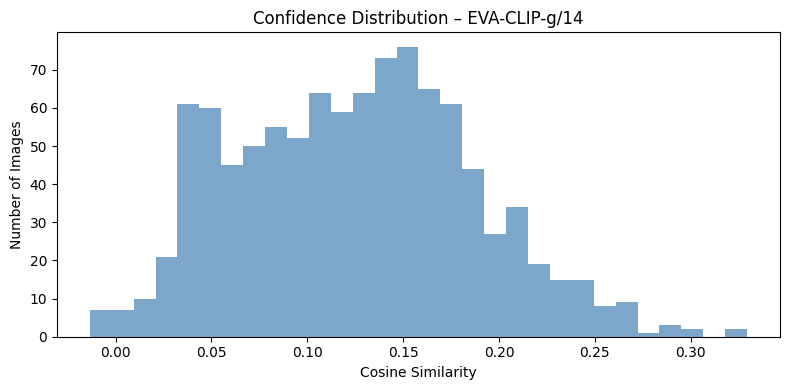

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(confidences, bins=30, alpha=0.7, color="steelblue")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence Distribution – EVA-CLIP-g/14")
plt.tight_layout()
plt.show()

In [11]:
output_csv = "/content/drive/MyDrive/flickr_data_subset/evaclip_sorted/evaclip_labels.csv"

df_results = pd.DataFrame({
    "file_name":  [os.path.basename(p) for p in valid_paths],
    "pred_label": results,
    "confidence": confidences
})

df_results.to_csv(output_csv, index=False)
print(f"Labels saved: {output_csv}")
print()
print("Distribution:")
print(df_results["pred_label"].value_counts())
print(f"\nTotal: {len(df_results)} images")

Labels saved: /content/drive/MyDrive/flickr_data_subset/evaclip_sorted/evaclip_labels.csv

Distribution:
pred_label
outdoor    952
indoor      57
Name: count, dtype: int64

Total: 1009 images


Evaluable images: 1007

Accuracy:        0.9255
Avg Confidence:  0.1248

              precision    recall  f1-score   support

      indoor       0.82      0.41      0.55       110
     outdoor       0.93      0.99      0.96       897

    accuracy                           0.93      1007
   macro avg       0.87      0.70      0.75      1007
weighted avg       0.92      0.93      0.91      1007



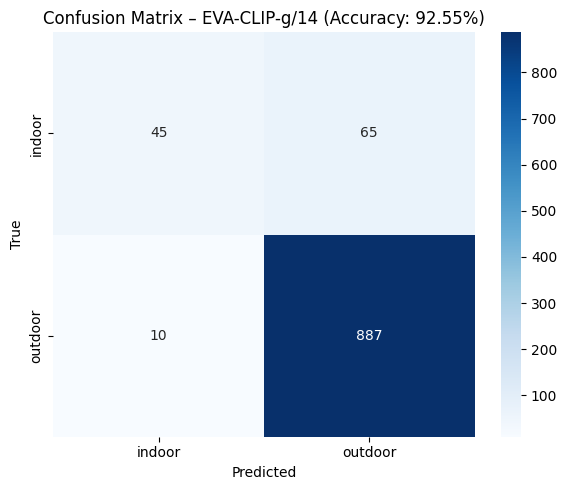

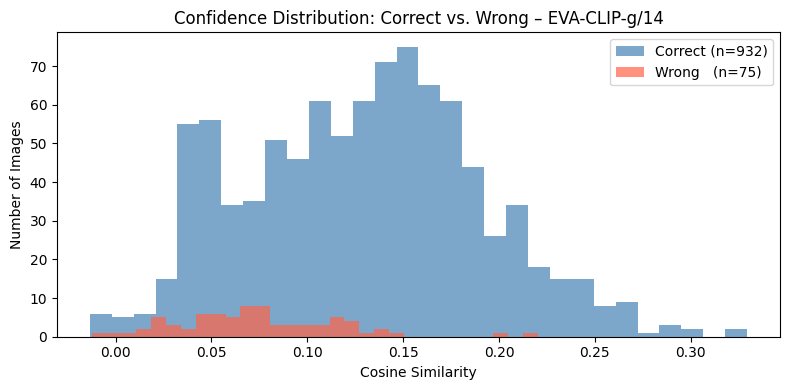


Top 10 most uncertain images:
            file_name true_label pred_label  confidence
55     image_1048.jpg    outdoor    outdoor   -0.013455
83    image_10696.jpg    outdoor    outdoor   -0.013417
1001   image_9231.jpg     indoor    outdoor   -0.012464
760     image_565.jpg     indoor     indoor   -0.011375
789     image_713.jpg     indoor     indoor   -0.008326
737    image_4652.jpg     indoor     indoor   -0.007389
978    image_7870.jpg     indoor     indoor   -0.005103
620      image_25.jpg     indoor    outdoor   -0.001160
735      image_45.jpg    outdoor    outdoor   -0.000368
902    image_7796.jpg    outdoor    outdoor    0.002275

── All files saved to: /content/drive/MyDrive/flickr_data_subset/evaclip_sorted/evaluation ──
  evaclip_metrics.csv
  evaclip_confusion_matrix.png
  evaclip_confidence_distribution.png
  evaclip_most_uncertain.csv


In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

output_dir = "/content/drive/MyDrive/flickr_data_subset/evaclip_sorted/evaluation"
os.makedirs(output_dir, exist_ok=True)

label_csv   = "/content/drive/MyDrive/flickr_data_subset/flickr_photos_sorted/photo_labels_indoor_outdoor_17042026.csv"
df_labels   = pd.read_csv(label_csv)
labels_dict = dict(zip(df_labels["file_name"], df_labels["Main_focus"]))

df_results["true_label"] = df_results["file_name"].map(labels_dict)
df_eval = df_results.dropna(subset=["true_label"])
print(f"Evaluable images: {len(df_eval)}")

true     = df_eval["true_label"].values
pred     = df_eval["pred_label"].values
accuracy = accuracy_score(true, pred)
avg_conf = float(np.mean(df_eval["confidence"]))

print(f"\nAccuracy:        {accuracy:.4f}")
print(f"Avg Confidence:  {avg_conf:.4f}")
print()
report = classification_report(true, pred,
                                target_names=sorted(categories),
                                output_dict=True)
print(classification_report(true, pred, target_names=sorted(categories)))

pd.DataFrame(report).transpose().to_csv(
    os.path.join(output_dir, "evaclip_metrics.csv"))

le = LabelEncoder()
le.classes_ = np.array(sorted(categories))
cm = confusion_matrix(le.transform(true), le.transform(pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – EVA-CLIP-g/14 (Accuracy: {accuracy:.2%})")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "evaclip_confusion_matrix.png"),
            dpi=150, bbox_inches='tight')
plt.show()

correct      = (df_eval["true_label"] == df_eval["pred_label"]).tolist()
conf_correct = [c for c, ok in zip(df_eval["confidence"], correct) if ok]
conf_wrong   = [c for c, ok in zip(df_eval["confidence"], correct) if not ok]

plt.figure(figsize=(8, 4))
plt.hist(conf_correct, bins=30, alpha=0.7,
         label=f"Correct (n={len(conf_correct)})", color="steelblue")
plt.hist(conf_wrong,   bins=30, alpha=0.7,
         label=f"Wrong   (n={len(conf_wrong)})",   color="tomato")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence Distribution: Correct vs. Wrong – EVA-CLIP-g/14")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "evaclip_confidence_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()

df_uncertain = df_eval.nsmallest(10, "confidence")[
    ["file_name", "true_label", "pred_label", "confidence"]]
print("\nTop 10 most uncertain images:")
print(df_uncertain)
df_uncertain.to_csv(os.path.join(output_dir, "evaclip_most_uncertain.csv"), index=False)

print(f"\n── All files saved to: {output_dir} ──")
print("  evaclip_metrics.csv")
print("  evaclip_confusion_matrix.png")
print("  evaclip_confidence_distribution.png")
print("  evaclip_most_uncertain.csv")